# CAN Bus Security Simulation - Log Analysis

This notebook analyzes the `eve.json` logs generated by Suricata IDS to detect and visualize potential threats in the CAN Bus simulation.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Define file path (relative to this notebook in code/ directory)
log_file_path = os.path.join(os.getcwd(), "..", "suricata_logs", "eve.json")

def parse_eve_log(file_path):
    data = []
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        # Try absolute path just in case
        file_path = "/Users/goureshmadye/Documents/can-bus-simulation/suricata_logs/eve.json"
    
    print(f"Reading log file: {file_path}")
    try:
        with open(file_path, 'r') as f:
            for line in f:
                try:
                    entry = json.loads(line)
                    if entry.get('event_type') == 'alert':
                        alert = entry.get('alert', {})
                        data.append({
                            'timestamp': entry.get('timestamp'),
                            'src_ip': entry.get('src_ip'),
                            'dst_ip': entry.get('dest_ip'),
                            'proto': entry.get('proto'),
                            'alert_signature': alert.get('signature'),
                            'category': alert.get('category'),
                            'severity': alert.get('severity')
                        })
                except json.JSONDecodeError:
                    continue
    except Exception as e:
        print(f"Error opening file: {e}")
        return pd.DataFrame()
        
    return pd.DataFrame(data)

df = parse_eve_log(log_file_path)

if not df.empty:
    # Convert timestamp
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    print(f"Successfully parsed {len(df)} alerts.")
    print(f"First alert: {df['timestamp'].min()}")
    print(f"Last alert: {df['timestamp'].max()}")
    duration = (df['timestamp'].max() - df['timestamp'].min()).total_seconds()
    print(f"Duration: {duration:.4f} seconds")
    display(df.head())
else:
    print("No alerts found or file parsing failed.")

Reading log file: /Users/goureshmadye/Documents/can-bus-simulation/code/../suricata_logs/eve.json
Successfully parsed 20 alerts.
First alert: 2026-02-04 16:30:41.657989+05:30
Last alert: 2026-02-04 16:30:41.660915+05:30
Duration: 0.0029 seconds


,timestamp,src_ip,dst_ip,proto,alert_signature,category,severity
0,2026-02-04 16:30:41.658602+05:30,192.168.0.4,192.168.0.10,UDP,CAN DoS Suspicious - Zero Payload (Sensor Fail...,,3
1,2026-02-04 16:30:41.657989+05:30,192.168.0.4,192.168.0.10,UDP,CAN DoS Suspicious - Zero Payload (Sensor Fail...,,3
2,2026-02-04 16:30:41.658914+05:30,192.168.0.4,192.168.0.10,UDP,CAN DoS Suspicious - Zero Payload (Sensor Fail...,,3
3,2026-02-04 16:30:41.658758+05:30,192.168.0.4,192.168.0.10,UDP,CAN DoS Suspicious - Zero Payload (Sensor Fail...,,3
4,2026-02-04 16:30:41.659070+05:30,192.168.0.4,192.168.0.10,UDP,CAN DoS Suspicious - Zero Payload (Sensor Fail...,,3


## Visualizations

/var/folders/my/gjs2rh1n4xvgx86h3p30wz5c0000gn/T/ipykernel_11172/448667252.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='alert_signature', data=df, order=df['alert_signature'].value_counts().index, palette='viridis')


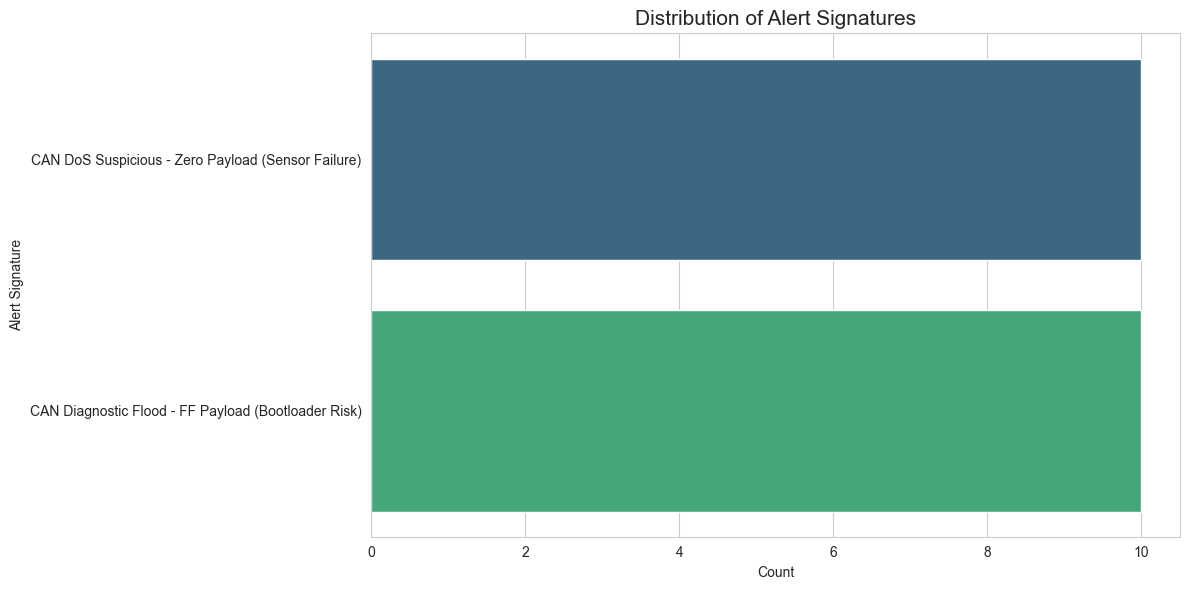

/var/folders/my/gjs2rh1n4xvgx86h3p30wz5c0000gn/T/ipykernel_11172/448667252.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='src_ip', data=df, order=df['src_ip'].value_counts().index, palette='magma')


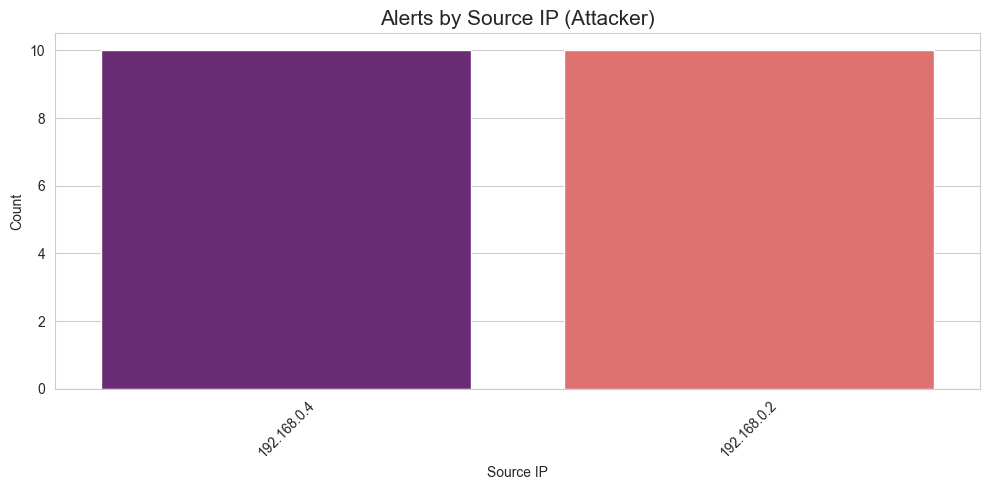


Alerts occurred in a burst of 0.0029 seconds. Plotting detailed timeline.


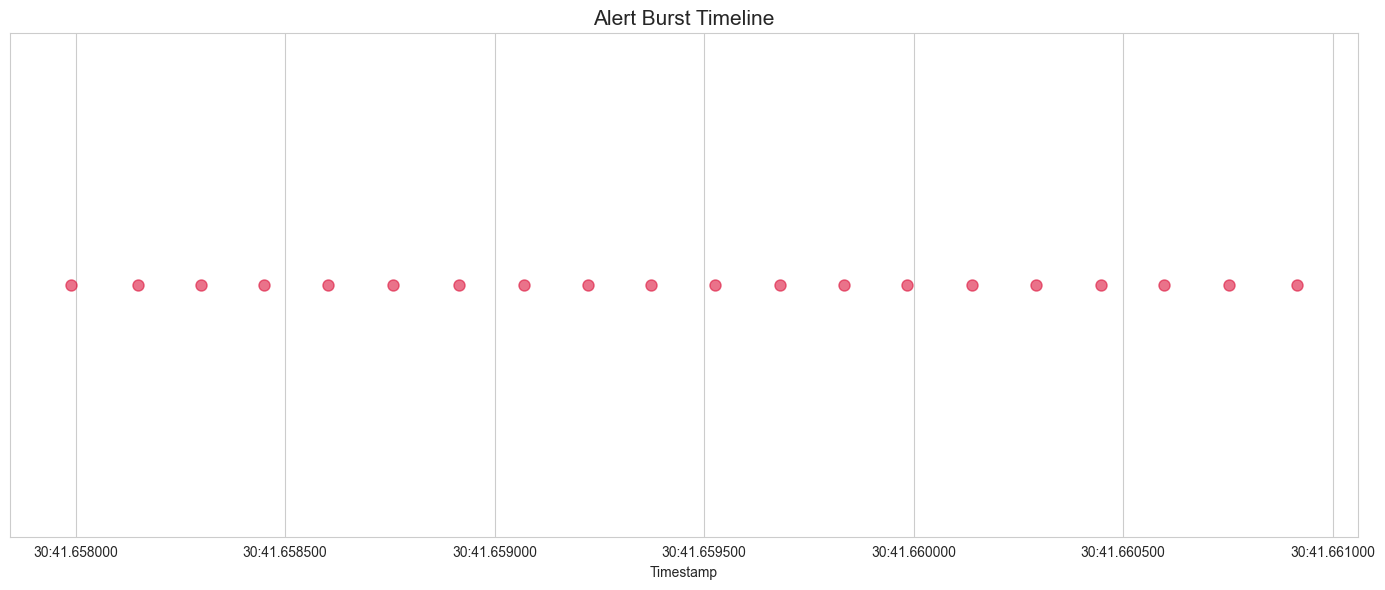

In [2]:
if not df.empty:
    # 1. Alert Signature Distribution
    try:
        plt.figure(figsize=(12, 6))
        sns.countplot(y='alert_signature', data=df, order=df['alert_signature'].value_counts().index, palette='viridis')
        plt.title('Distribution of Alert Signatures', fontsize=15)
        plt.xlabel('Count')
        plt.ylabel('Alert Signature')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error plotting alert distribution: {e}")

    # 2. Source IP Distribution
    try:
        plt.figure(figsize=(10, 5))
        sns.countplot(x='src_ip', data=df, order=df['src_ip'].value_counts().index, palette='magma')
        plt.title('Alerts by Source IP (Attacker)', fontsize=15)
        plt.xlabel('Source IP')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error plotting IP distribution: {e}")

    # 3. Timeline of Alerts
    # Check if duration is significant enough for resampling
    try:
        duration = (df['timestamp'].max() - df['timestamp'].min()).total_seconds()
        
        if duration > 1.0:
            # Significant duration, use resampling
            plt.figure(figsize=(14, 6))
            timeline = df.set_index('timestamp').resample('1s').size()
            timeline.plot(kind='line', marker='o', color='crimson')
            plt.title('Alerts Over Time (Aggregated per Second)', fontsize=15)
            plt.xlabel('Time')
            plt.ylabel('Alerts per Second')
            plt.tight_layout()
            plt.show()
        else:
            # Burst event, plot individual events
            print(f"\nAlerts occurred in a burst of {duration:.4f} seconds. Plotting detailed timeline.")
            plt.figure(figsize=(14, 6))
            # Plot simply alert index vs time or just points on a line
            plt.plot(df['timestamp'], [1]*len(df), 'o', color='crimson', markersize=8, alpha=0.6)
            plt.title('Alert Burst Timeline', fontsize=15)
            plt.xlabel('Timestamp')
            plt.yticks([])
            plt.tight_layout()
            plt.show()
    except Exception as e:
        print(f"Error plotting timeline: {e}")
else:
    print("No data to visualize.")